In [1]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns


In [ ]:
def read_cococonet(species_1):
    """[Takes a species name in any format, and returns a CoCoConet for that species]

    Args:
        species_1 ([str]): [Species in CoCoCoNet]

    Returns:
        [Panda Dataframe]: [GenexGene Matrix]
    """
    import h5py
    import pandas as pd
    import Name_resolver as nr

    assert (type(species_1) == str ), 'Species Must Be A String'

    common_name_of_species = nr.species_name_resolver(species_1= species_1, desired_type='common')


    cococonet_map = pd.read_csv('/vault/transfer/passala/Generated_Tables/Reference_tables/All_CoCoCoNet_Paths.csv')
    file_location = cococonet_map['Path'].loc[cococonet_map['Common Name'] == common_name_of_species].item()

    net = h5py.File(file_location,'r')
    agg_dataset = net['agg'] 
    row_dataset = net['row']
    col_dataset = net['col']
    row_gene_list = []
    for gene in row_dataset:
        row_gene_list.append(gene.decode('UTF-8'))
    col_gene_list = []
    for gene in col_dataset: 
        col_gene_list.append(gene.decode('UTF-8'))
    net_df = pd.DataFrame(data = agg_dataset[:,:], index = row_gene_list, columns = col_gene_list)
    net.close()
    return net_df 

In [3]:
low_heat_sorg_1 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/Sorghum_rice_heat_stress/Rice/control_1hr50min/rice_control_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
low_heat_sorg_2 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/Sorghum_rice_heat_stress/Rice/control_1hr50min/rice_control_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)



low_heat_sorg= pd.DataFrame(
    data=zip(
        low_heat_sorg_1["Reads"],
        low_heat_sorg_2["Reads"],

    ),
    columns=["Sorg Cold Rep 1", "Sorg Cold Rep 2" ,],
    index=low_heat_sorg_1.index,
)


In [4]:
low_heat_sorg

,Sorg Cold Rep 1,Sorg Cold Rep 2
Os01g0100100,1366,1468
Os01g0100200,1,5
Os01g0100300,0,0
Os01g0100400,152,145
Os01g0100466,0,0
...,...,...
Os12g0641200,9,2
Os12g0641300,5,0
Os12g0641400,3586,3617
Os12g0641500,2472,2774


In [5]:
high_heat_sorg_1 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/Sorghum_rice_heat_stress/Rice/heat_1hr50/rice_heat_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_sorg_2 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/Sorghum_rice_heat_stress/Rice/heat_1hr50/rice_heat_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)


high_heat_sorg= pd.DataFrame(
    data=zip(
        high_heat_sorg_1["Reads"],
        high_heat_sorg_2["Reads"],

    ),
    columns=["Sorg Hot Rep 1", "Sorg Hot Rep 2" ,],
    index=high_heat_sorg_1.index,
)


In [6]:
high_heat_sorg

,Sorg Hot Rep 1,Sorg Hot Rep 2
Os01g0100100,858,1060
Os01g0100200,1,1
Os01g0100300,0,0
Os01g0100400,99,163
Os01g0100466,0,0
...,...,...
Os12g0641200,18,41
Os12g0641300,0,12
Os12g0641400,6404,8000
Os12g0641500,2194,2737


In [7]:
combined_sorg = pd.concat([low_heat_sorg, high_heat_sorg], axis=1)
combined_sorg

,Sorg Cold Rep 1,Sorg Cold Rep 2,Sorg Hot Rep 1,Sorg Hot Rep 2
Os01g0100100,1366,1468,858,1060
Os01g0100200,1,5,1,1
Os01g0100300,0,0,0,0
Os01g0100400,152,145,99,163
Os01g0100466,0,0,0,0
...,...,...,...,...
Os12g0641200,9,2,18,41
Os12g0641300,5,0,0,12
Os12g0641400,3586,3617,6404,8000
Os12g0641500,2472,2774,2194,2737


In [8]:
sorg_metadata = pd.DataFrame(
    columns=["Temp"],
    data=["Cold", "Cold", "Hot", "Hot",],
    index=[
        "Sorg Cold Rep 1",
        "Sorg Cold Rep 2",
        "Sorg Hot Rep 1",
        "Sorg Hot Rep 2",
    ],
)

In [9]:
low_heat_maize_1 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_heat_seedling/Maize_control/Run_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
low_heat_maize_2 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_heat_seedling/Maize_control/Run_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
low_heat_maize_3 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_heat_seedling/Maize_control/Run_3ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)


low_heat_maize = pd.DataFrame(
    data=zip(
        low_heat_maize_1["Reads"],
        low_heat_maize_2["Reads"],
        low_heat_maize_3["Reads"],

    ),
    columns=["maize Cold Rep 1", "maize Cold Rep 2", "maize Cold Rep 3",],
    index=low_heat_maize_1.index,
)


In [10]:
low_heat_maize.index = low_heat_maize.index.str.split(':').str[1]
low_heat_maize

,maize Cold Rep 1,maize Cold Rep 2,maize Cold Rep 3
Zm00001d000055,4,11,7
Zm00001d000058,0,0,0
Zm00001d000060,1060,2529,2842
Zm00001d000061,8,7,14
Zm00001d000062,1,0,0
...,...,...,...
GRMZM5G885905,0,0,0
GRMZM5G866761,0,0,0
GRMZM5G818111,1,0,0
GRMZM5G866064,0,0,0


In [11]:
high_heat_maize_rep_1 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_heat_seedling/Maize_heat/Run_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_maize_rep_2 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_heat_seedling/Maize_heat/Run_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_maize_rep_3 = pd.read_csv(
    "/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_heat_seedling/Maize_heat/Run_3ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)


high_heat_maize = pd.DataFrame(
    data=zip(
        high_heat_maize_rep_1["Reads"],
        high_heat_maize_rep_2["Reads"],
        high_heat_maize_rep_3["Reads"],
        
    ),
    columns=["maize Hot Rep 1", "maize Hot Rep 2", "maize Hot Rep 3", ],
    index=low_heat_maize_1.index,
)

In [12]:
high_heat_maize.index = high_heat_maize.index.str.split(':').str[1]
high_heat_maize

,maize Hot Rep 1,maize Hot Rep 2,maize Hot Rep 3
Zm00001d000055,1,4,3
Zm00001d000058,0,0,0
Zm00001d000060,320,2205,1824
Zm00001d000061,0,0,0
Zm00001d000062,0,0,0
...,...,...,...
GRMZM5G885905,0,0,0
GRMZM5G866761,0,0,0
GRMZM5G818111,0,0,0
GRMZM5G866064,0,0,0


In [13]:
combined_maize = pd.concat([high_heat_maize, low_heat_maize], axis=1)

In [14]:
combined_maize = combined_maize.T

In [15]:

combined_sorg = combined_sorg.T


In [16]:
combined_sorg.to_csv("/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/rice_reads.csv")
#combined_maize.to_csv("/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_reads.csv")

In [17]:
maize_metadata = pd.DataFrame(
    columns=["Temp"],
    data=["Hot", "Hot", "Hot","Cold","Cold", "Cold"],
    index=[
        "maize Hot Rep 1",
        "maize Hot Rep 2",
        "maize Hot Rep 3",
        "maize Cold Rep 1",
        "maize Cold Rep 2",
        "maize Cold Rep 3",
    ],
)

In [19]:
genes_to_keep_sorg = combined_sorg.columns[combined_sorg.sum(axis=0) >= 100]
combined_sorg = combined_sorg[genes_to_keep_sorg]
inference_sorg = DefaultInference(n_cpus=30)
dds_sorg = DeseqDataSet(
    counts=combined_sorg,
    metadata=sorg_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference_sorg,
)
dds_sorg.deseq2()
stat_res_sorg = DeseqStats(dds_sorg, inference=inference_sorg, contrast=["Temp", "Hot", "Cold"])
stat_res_sorg.summary()

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_1638488/197680030.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds_sorg = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...
... done in 1.07 seconds.

Fitting dispersion trend curve...
... done in 0.30 seconds.

/home/mikepassal/miniconda3/envs/Family_coexpression/lib/python3.14/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 1.07 seconds.

Fitting LFCs...
... done in 1.15 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                 baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Os01g0100100  1173.668182       -0.452103  0.132250 -3.418541  6.295781e-04   
Os01g0100400   138.023943       -0.092911  0.294876 -0.315085  7.526969e-01   
Os01g0100500  1447.758803        0.366720  0.126195  2.905964  3.661234e-03   
Os01g0100600   367.754989        0.446220  0.190792  2.338774  1.934712e-02   
Os01g0100700  1313.645813       -0.097851  0.131237 -0.745600  4.559090e-01   
...                   ...             ...       ...       ...           ...   
Os12g0640800   892.894545        0.405430  0.142914  2.836888  4.555556e-03   
Os12g0640900    94.457475       -0.045878  0.350368 -0.130942  8.958213e-01   
Os12g0641100  3525.819092        0.748280  0.117151  6.387332  1.688044e-10   
Os12g0641400  5446.909213        1.106842  0.111796  9.900548  4.139999e-23   
Os12g0641500  2526.661779        0.023141  0.112206  0.206239  8.366041e-01 

... done in 0.80 seconds.



In [20]:
genes_to_keep = combined_maize.columns[combined_maize.sum(axis=0) >= 100]
combined_maize = combined_maize[genes_to_keep]
inference = DefaultInference(n_cpus=30)
dds = DeseqDataSet(
    counts=combined_maize,
    metadata=maize_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()
stat_res_maize = DeseqStats(dds, inference=inference, contrast=["Temp", "Hot", "Cold"])
stat_res_maize.summary()

/tmp/ipykernel_1638488/3353173324.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.16 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 1.31 seconds.

Fitting LFCs...
... done in 1.01 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Zm00001d000060  1473.507174        0.325284  0.147589  2.203988  2.752522e-02   
Zm00001d000070   388.139697       -0.124086  0.252856 -0.490738  6.236114e-01   
Zm00001d000071   581.085478        0.151634  0.115814  1.309294  1.904347e-01   
Zm00001d000072   373.021330       -0.748299  0.133125 -5.621032  1.898203e-08   
Zm00001d000299   112.092484        0.092041  0.196256  0.468987  6.390789e-01   
...                     ...             ...       ...       ...           ...   
Zm00001d048574   724.741816        0.442728  0.128063  3.457123  5.459762e-04   
Zm00001d048575   601.128259       -0.768892  0.328053 -2.343801  1.908833e-02   
Zm00001d048577   301.100030       -0.255287  0.187023 -1.365004  1.722517e-01   
GRMZM5G836994    127.749623       -1.297697  0.314956 -4.120242  3.784748e-05   
GRMZM5G811749     32.597150       -1.096250  0.407051 

... done in 0.92 seconds.



In [21]:
full_results_maize = stat_res_maize.results_df
full_results_maize
full_results_sorg = stat_res_sorg.results_df

In [22]:
#full_results_maize.to_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/maize_gene_results.csv')
full_results_sorg.to_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/rice_gene_results.csv')

/tmp/ipykernel_1627614/3696312688.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(x=full_results_maize['log2FoldChange'],y=full_results_maize['padj'].apply(lambda x:-np.log10(x)),s=1,label="Not significant")
/tmp/ipykernel_1627614/3696312688.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(x=up_arabi['log2FoldChange'],y=up_arabi['padj'].apply(lambda x:-np.log10(x)),s=3,label="Up-regulated",color="red")


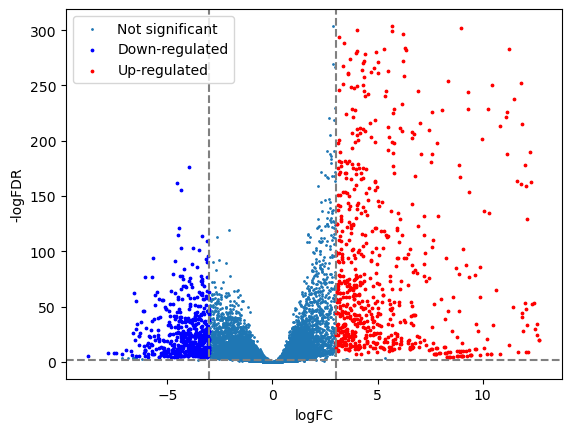

In [34]:
plt.scatter(x=full_results_maize['log2FoldChange'],y=full_results_maize['padj'].apply(lambda x:-np.log10(x)),s=1,label="Not significant")

# highlight down- or up- regulated genes
down_arabi = full_results_maize[(full_results_maize['log2FoldChange']<=-3)&(full_results_maize['padj']<=0.0001)]
up_arabi = full_results_maize[(full_results_maize['log2FoldChange']>=3)&(full_results_maize['padj']<=0.0001)]

plt.scatter(x=down_arabi['log2FoldChange'],y=down_arabi['padj'].apply(lambda x:-np.log10(x)),s=3,label="Down-regulated",color="blue")
plt.scatter(x=up_arabi['log2FoldChange'],y=up_arabi['padj'].apply(lambda x:-np.log10(x)),s=3,label="Up-regulated",color="red")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(-3,color="grey",linestyle="--")
plt.axvline(3,color="grey",linestyle="--")
plt.axhline(2,color="grey",linestyle="--")
plt.legend()

In [25]:
up_arabi

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Locus,,,,,,
AT1G03070,244.041301,4.909129,0.676055,7.261436,3.830035e-13,1.623916e-11
AT1G03470,272.881762,4.077672,0.438625,9.296489,1.451593e-20,1.559438e-18
AT1G07050,78.272039,5.614861,0.772109,7.272106,3.539261e-13,1.515305e-11
AT1G07400,5542.233763,4.257430,0.479868,8.872089,7.178661e-19,6.547163e-17
AT1G08560,64.164207,3.086038,0.460190,6.706012,2.000148e-11,6.236203e-10
...,...,...,...,...,...,...
ATMG01170,114.058124,3.130845,0.402513,7.778240,7.354054e-15,3.999281e-13
ATMG01190,58.267544,5.149719,0.615456,8.367329,5.893919e-17,4.229853e-15
ATMG01200,247.691931,4.696561,0.372497,12.608320,1.899999e-36,6.931433e-34


In [26]:
up

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
LOC104645776,16.743984,5.407347,1.185733,4.560342,5.107049e-06,1.433444e-05
LOC101256908,636.987165,5.521131,0.434430,12.708905,5.276819e-37,1.509383e-35
LOC101245874,1193.548538,3.648663,0.271307,13.448487,3.142367e-41,1.126178e-39
MIR6026,348.085222,4.175639,0.238158,17.533045,8.015952e-69,8.685991e-67
JMJ524,103.081531,3.221060,0.407344,7.907461,2.626907e-15,1.976726e-14
...,...,...,...,...,...,...
CQW56_mgp29,23.900533,4.075286,0.794088,5.132033,2.866288e-07,9.469135e-07
CQW56_mgp16,115.817361,4.108246,0.454575,9.037554,1.602165e-19,1.651566e-18
CQW56_mgp11,179.570123,4.119752,0.461701,8.922987,4.538792e-19,4.524301e-18
CQW56_mgp10,81.092169,3.543048,0.562626,6.297344,3.027894e-10,1.409218e-09


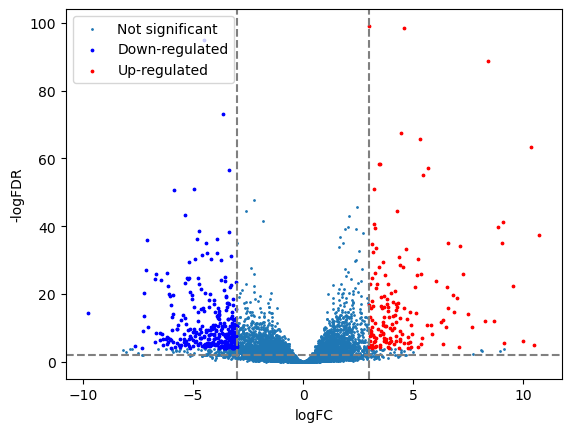

In [35]:
plt.scatter(x=full_results_sorg['log2FoldChange'],y=full_results_sorg['padj'].apply(lambda x:-np.log10(x)),s=1,label="Not significant")

# highlight down- or up- regulated genes
down = full_results_sorg[(full_results_sorg['log2FoldChange']<=-3)&(full_results_sorg['padj']<=0.0001)]
up = full_results_sorg[(full_results_sorg['log2FoldChange']>=3)&(full_results_sorg['padj']<=0.0001)]

plt.scatter(x=down['log2FoldChange'],y=down['padj'].apply(lambda x:-np.log10(x)),s=3,label="Down-regulated",color="blue")
plt.scatter(x=up['log2FoldChange'],y=up['padj'].apply(lambda x:-np.log10(x)),s=3,label="Up-regulated",color="red")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(-3,color="grey",linestyle="--")
plt.axvline(3,color="grey",linestyle="--")
plt.axhline(2,color="grey",linestyle="--")
plt.legend()